In [1]:
import os
import glob
import pandas as pd
import numpy as np
from scipy import signal
import soundfile as sf
import matplotlib.pyplot as plt
import funciones as fn

In [2]:
# Constantes  
G = 10**(3/10)     # Cociente de octava base 10: frec * G = octava de frec. G_10 approx= 2. Ver definicion en norma 61260
fs = 44100     # frec de muestreo
f_r = 1000     # Hz, frec de referencia
# f_m_octava = [G**i * f_r for i in range(-5, 5)]     # frecs centrales para anchos de banda de octava
f_m_tercios = [G**(i/3) * f_r for i in range(-10, 2)]     # frecs centrales para anchos de banda de tercio de octava
N = 10     # Orden de los filtros

 - Filtrar el audio por bandas y guardar el valor (N°Mic=Ang Vertical, Ang Horizontal, Frec, dB) en un csv.
 - Recorrer el o los csv prara obtener un slice de la esfera. 
 - Ver como se arma el ballon

In [3]:
path_wavs_cris = os.path.join('.', 'Medicion_Cristian', 'Media')
wavs_cris = np.array(glob.glob(os.path.join(path_wavs_cris, '*.wav')))
wavs_cris_mic_1 = wavs_cris[['mic_1_ang' in os.path.basename(wav) for wav in wavs_cris]]

path_wavs_juli = os.path.join('.', 'Medicion_Juli', 'Media')
wavs_juli = np.array(glob.glob(os.path.join(path_wavs_juli, '*.wav')))
wavs_juli_mic_1 = wavs_juli[['mic_1_ang' in os.path.basename(wav) for wav in wavs_juli]]

In [4]:
filtros_tercio = fn.sos_filter_bank(3, f_m_tercios, N, fs, G)

In [5]:
file_prefix = 'mic_1_ang_forte_'
res = []
res_315 = []
res_315_arm = []
for i in range(0, 181, 10):
    wav_path = os.path.join(path_wavs_juli, f'{file_prefix}{i}.wav')
    wav, fs_wav = sf.read(wav_path)
    
    wav_por_tercios = fn.sos_filter_audio(wav, *filtros_tercio)
    wav_tercios_spl = [fn.signal_to_SPL(wav_ter) for wav_ter in wav_por_tercios]
    wav_tercios_leq = [fn.Leq(wav_ter_spl) for wav_ter_spl in wav_tercios_spl]

    # wav_recortado = wav[410000:]
    # wav_por_tercios_315 = fn.sos_filter_audio(wav_recortado, *filtros_tercio)
    # wav_tercios_spl_315 = [fn.signal_to_SPL(wav_ter_315) for wav_ter_315 in wav_por_tercios_315]
    # wav_tercios_leq_315 = [fn.Leq(wav_ter_spl) for wav_ter_spl in wav_tercios_spl_315]

    # wav_recortado_arm = wav[300000:410000]
    # wav_por_tercios_315_arm = fn.sos_filter_audio(wav_recortado_arm, *filtros_tercio)
    # wav_tercios_spl_315_arm = [fn.signal_to_SPL(wav_ter_315_arm) for wav_ter_315_arm in wav_por_tercios_315_arm]
    # wav_tercios_leq_315_arm = [fn.Leq(wav_ter_spl_arm) for wav_ter_spl_arm in wav_tercios_spl_315_arm]

    for j in range(len(f_m_tercios)):
        res.append((1, 0, i, f_m_tercios[j], wav_tercios_leq[j]))
        # res_315.append((1, 0, i, f_m_tercios[j], wav_tercios_leq_315[j]))
        # res_315_arm.append((1, 0, i, f_m_tercios[j], wav_tercios_leq_315_arm[j]))

In [6]:
df = pd.DataFrame(res, columns=['Mic', 'Ang Ver', 'Ang Hor', 'Frec Banda', 'SPL'])
# df_315 = pd.DataFrame(res_315, columns=['Mic', 'Ang Ver', 'Ang Hor', 'Frec Banda', 'SPL'])
# df_315_arm = pd.DataFrame(res_315_arm, columns=['Mic', 'Ang Ver', 'Ang Hor', 'Frec Banda', 'SPL'])

In [7]:
# polar_315_f0_arm = df[df['Frec Banda'] == 316.22776601683796]
# polar_315_f0 = df_315[df_315['Frec Banda'] == 316.22776601683796]
# polar_315_arm = df_315_arm[df_315_arm['Frec Banda'] == 316.22776601683796]

# angles = polar_315_f0['Ang Hor'].values
# rad = np.deg2rad(angles)

# spl_315_f0_arm = polar_315_f0_arm['SPL'].values
# spl_315_f0 = polar_315_f0['SPL'].values
# spl_315_arm = polar_315_arm['SPL'].values

In [8]:
# Create a polar plot
# fig = plt.figure(figsize=(10, 5))
# ax = plt.subplot(projection='polar')
# ax.set_theta_direction(-1)  # Dirección en sentido horario
# ax.set_theta_offset(np.pi / 2.0)  # Desplazar para que 0º esté en la parte superior
# ax.set_thetamin(0)
# ax.set_thetamax(180)
# # ax.set_rticks([-20,-15,-10,-5, 0])
# # ax.set_ylim(-19, 1)

# plt.polar(rad, spl_315_f0_arm, label='315Hz f0 + arm')
# plt.polar(rad, spl_315_f0, label='315Hz f0')
# plt.polar(rad, spl_315_arm, label='315Hz arm')

# plt.legend()
# plt.show()
# # fig.savefig("Patron_polar_Vigoole_1.jpg")

### Ploteo de los filtros

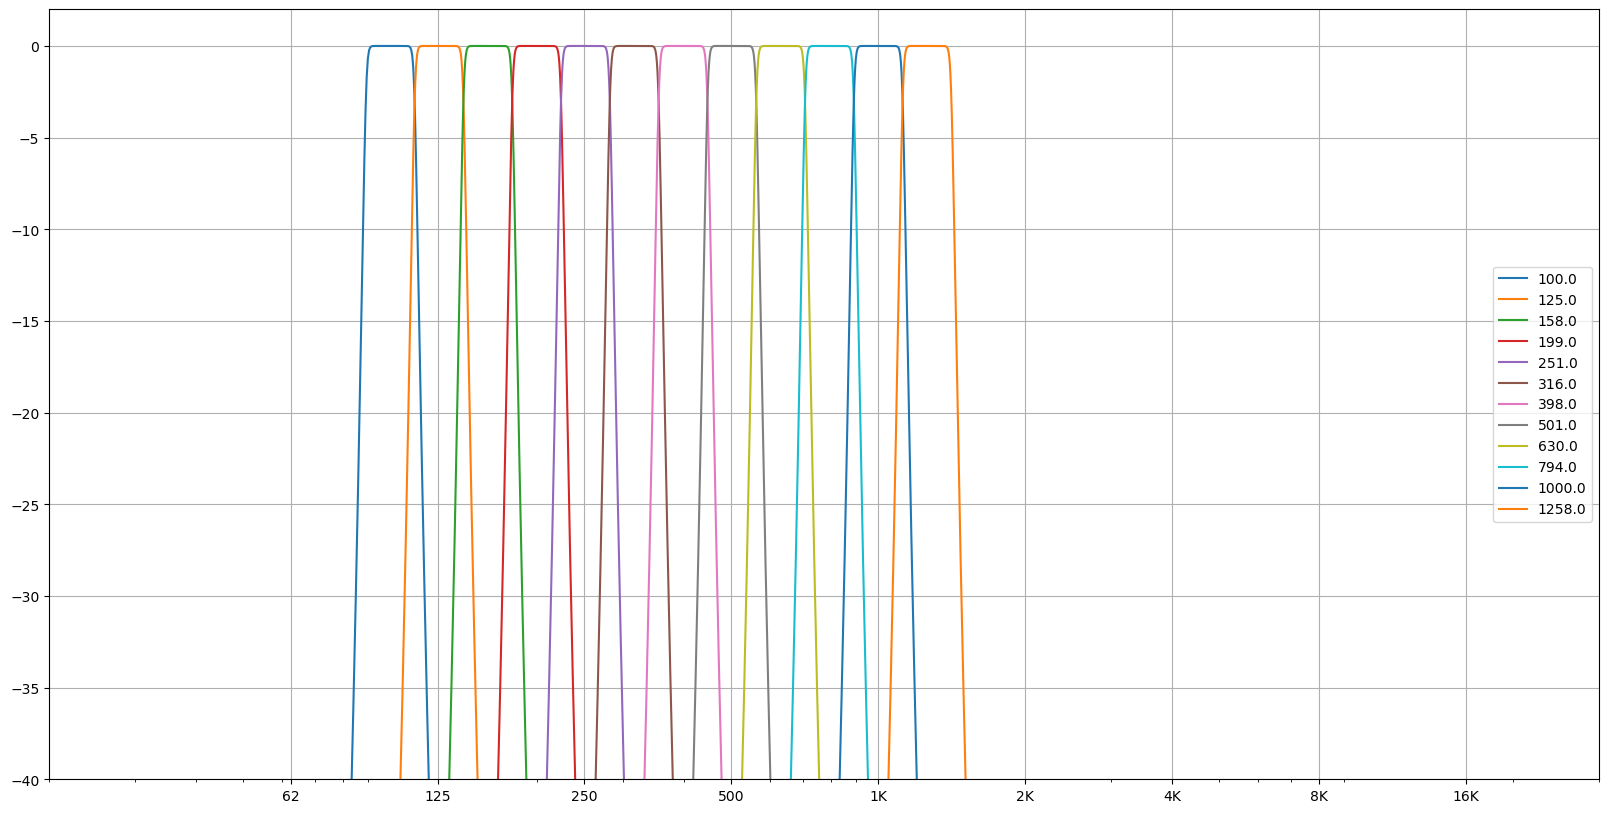

In [9]:
Hs = []
eps = np.finfo(float).eps
for sos in filtros_tercio:
    Wn, H = signal.sosfreqz(sos, fs=fs, worN=fs)
    Hs.append(H)

plt.figure(figsize=(20,10))
for i in range(len(Hs)):
    plt.plot(Wn, 20*np.log10(abs(Hs[i])+eps), label=np.floor(f_m_tercios[i]))
x_ticks = [62.5*2**(n) for n in range(9)]
x_labels = ['62', '125', '250', '500'] + [str(2**(n)) + 'K' for n in range(5)]

plt.xscale('log')
plt.xticks(x_ticks, x_labels)
plt.xlim(20, 30000)
plt.ylim(-40, 2)
plt.legend(loc='right')
plt.grid()

### Plot y Play señal filtrada

In [10]:
# wav_path = os.path.join(path_wavs_juli, f'{file_prefix}{0}.wav')
# wav, fs_wav = sf.read(wav_path)
# wav_por_tercios = fn.sos_filter_audio(wav, *filtros_tercio)
# wav_tercios_spl = [fn.signal_to_SPL(wav_ter) for wav_ter in wav_por_tercios]
# wav_tercios_leq = [fn.Leq(wav_ter_spl) for wav_ter_spl in wav_tercios_spl]

In [11]:
frame_length = int(np.ceil(fs_wav * 16.6 / 1000))
hop_length = frame_length // 2

In [12]:
hop_length

366

In [15]:
res = fn.process_audio(wav, filtros_tercio, frame_length, hop_length)
res

NameError: name 'calculate_windowed_energy_beta' is not defined

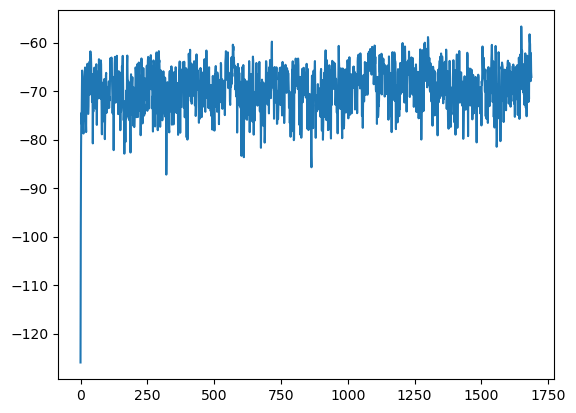

In [ ]:
plt.plot(res[4])

316.22776601683796
398.1071705534973
501.18723362727235
630.9573444801932


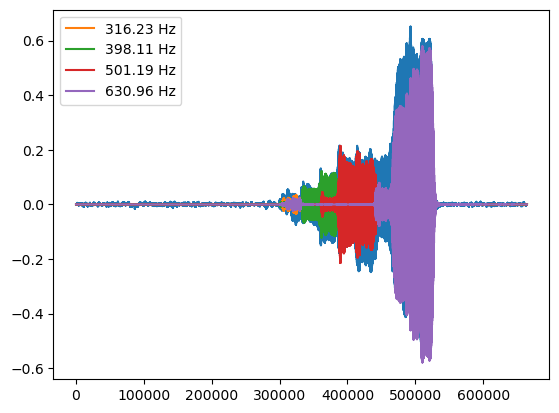

In [ ]:
plt.plot(wav)
for i in range(len(filtros_tercio[5:9])):
    plt.plot(wav_por_tercios[i+5], label=f'{f_m_tercios[i+5]:.2f} Hz')
    print(f_m_tercios[i+5])

plt.legend(loc='upper left')
    

1000.0


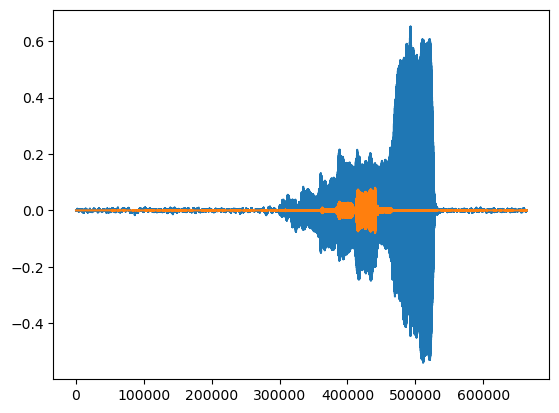

In [ ]:
plt.plot(wav)
# for i in range(len(filtros_tercio)):
i = 10
plt.plot(wav_por_tercios[i])
# plt.xlim(400000, 700000)
print(f_m_tercios[i])

(0.0, 50000.0)

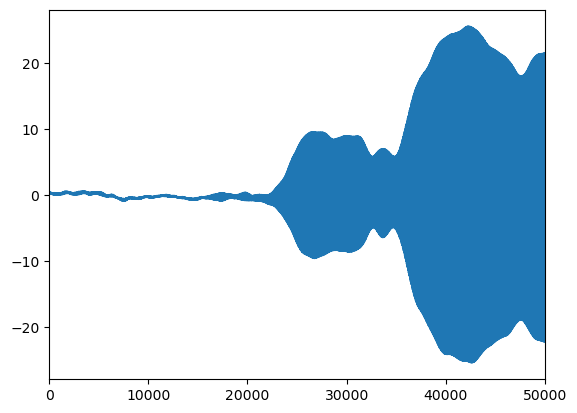

In [ ]:
# wav = wav[300000:600000]
# acf = np.correlate(wav, wav, mode='full')
acf = acf[acf.size // 2:]  # Tomar solo la mitad positiva de la correlación
plt.plot(acf)
plt.xlim(0, 50000)

In [ ]:
Audio(wav_por_tercios[idx], rate=fs_wav, normalize=True)

NameError: name 'Audio' is not defined

In [ ]:
Audio(wav, rate=fs_wav, normalize=True)

In [ ]:
# Suponiendo que tenes una lista de audios, uno por cada ángulo medido
# y querés procesar la banda de frecuencia en el índice 5 (ej: 1000 Hz)

num_angles = len(audio_measurements)
band_to_analyze = 5 

# Lista para guardar la evolución temporal de cada ángulo
all_angles_db = []

for raw_audio in audio_measurements:
    evolution_db = process_frequency_band(
        raw_audio=raw_audio,
        sos_filter_bank=mis_filtros_sos,
        band_index=band_to_analyze,
        frame_length=2048, # O el tamaño que defina tu STFT
        hop_length=512
    )
    all_angles_db.append(evolution_db)

# Matriz final 2D: (Tiempo x Ángulos)
# Lista para ser interpolada y enviada a PyQtGraph
spatial_matrix_db = np.column_stack(all_angles_db)